# Gallifrey

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as mpl
import torch
import torch.nn as nn
import warnings
import joblib
import os

from scipy.fft import fft, fftfreq
from scipy import signal

In [18]:
warnings.filterwarnings('ignore')

In [19]:
mpl.style.use('dark_background')

In [20]:
PALETTE = ['#00D4FF', '#FF6B35', '#7FFF00', '#FFD700', '#FF69B4', '#9B59B6']
sns.set_palette(PALETTE)

In [21]:
os.makedirs('models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

In [25]:
np.random.seed(42)
torch.manual_seed(42)
print("42 Ready :D")

42 Ready :D


## 1. Data Loading and EDA

In [27]:
DT_PATH  = 'digitaltwin.csv'
ACC_PATH = 'sensor.csv'

In [28]:
dt  = pd.read_csv(DT_PATH,  parse_dates=['Timestamp'])
acc  = pd.read_csv(ACC_PATH,  parse_dates=['Timestamp'])

In [34]:
print("----- Digital Twin: -----")
print(f"Shape: {dt.shape} Time range: {dt["Timestamp"].min()} → {dt["Timestamp"].max()}\n")
print(dt.head(5))

print("*"*100)

print("----- Accelerometer: -----")
print(f"Shape: {acc.shape}  |  Time range: {acc["Timestamp"].min()} → {acc["Timestamp"].max()}")
print(dt.head(5))

----- Digital Twin: -----
Shape: (43200, 54) Time range: 2023-01-01 00:00:00 → 2023-01-30 23:59:00

            Timestamp  Strain_microstrain  Deflection_mm  Vibration_ms2  \
0 2023-01-01 00:00:00                 NaN      12.663104       1.275955   
1 2023-01-01 00:01:00          599.936448      12.235297       0.716857   
2 2023-01-01 00:02:00          573.878472      12.447144       0.834753   
3 2023-01-01 00:03:00          550.457302      12.554883       1.004917   
4 2023-01-01 00:04:00          572.829960      12.598818       1.176253   

   Tilt_deg  Displacement_mm  Crack_Propagation_mm  Corrosion_Level_percent  \
0  0.587340        22.576518             -0.000083                 0.002910   
1  0.657122        21.202649              0.000092                 0.004601   
2  0.615011              NaN             -0.000377                 0.005115   
3  0.617999        21.551945             -0.000646                 0.005505   
4  0.633534        21.711292              0.000247    

## 2. Missing Values Analysis

In [37]:
def missing_report(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'missing': missing, 'pct': pct})
    report = report[report['missing'] > 0].sort_values('pct', ascending=False)
    print(f'\n{name}: {len(report)} columns with missing values')
    return report

dt_missing  = missing_report(dt,  'Digital Twin')
acc_missing = missing_report(acc, 'Accelerometer')
display(dt_missing.head(15))


Digital Twin: 53 columns with missing values

Accelerometer: 5 columns with missing values


,missing,pct
Vibration_Anomaly_Location,34155,79.06
Strain_microstrain,1821,4.22
Humidity_percent,1783,4.13
Estimated_Repair_Cost_USD_incremental,1771,4.10
Wind_Direction_deg,1768,4.09
Landslide_Ground_Movement,1765,4.09
Abnormal_Traffic_Load_Surges,1763,4.08
High_Winds_Storms,1758,4.07
Vehicle_Load_tons,1756,4.06
Tilt_deg,1753,4.06


In [39]:
# statistics for key structural columns
KEY_STRUCTURAL = [
    'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2',
    'Displacement_mm', 'Crack_Propagation_mm', 'Corrosion_Level_percent',
    'Modal_Frequency_Hz', 'Structural_Health_Index_SHI',
    'Probability_of_Failure_PoF'
]

dt[KEY_STRUCTURAL].describe().T.style.background_gradient(cmap='RdYlGn_r')

,count,mean,std,min,25%,50%,75%,max
Strain_microstrain,41379.000000,851.950836,351.908310,363.529753,618.866446,734.476653,1072.661680,4074.893156
Deflection_mm,41467.000000,15.145403,3.824032,6.889697,12.447132,14.986160,17.090508,30.389080
Vibration_ms2,41478.000000,1.339495,0.979641,0.637735,1.000030,1.198123,1.532924,15.086480
Displacement_mm,41473.000000,22.703596,1.627841,18.964441,21.387484,22.361439,23.985103,27.630262
Crack_Propagation_mm,41494.000000,0.015036,0.009338,-0.001531,0.007511,0.015024,0.022526,0.519706
Corrosion_Level_percent,41531.000000,0.149950,0.086731,-0.010256,0.074979,0.150101,0.224839,0.312679
Modal_Frequency_Hz,41481.000000,1.895313,0.100269,1.353801,1.825477,1.895834,1.968278,2.235211
Structural_Health_Index_SHI,41500.000000,0.815885,0.052818,0.292081,0.797134,0.822936,0.845468,0.907657
Probability_of_Failure_PoF,41456.000000,0.034029,0.017626,0.019160,0.027351,0.030689,0.035370,0.708676


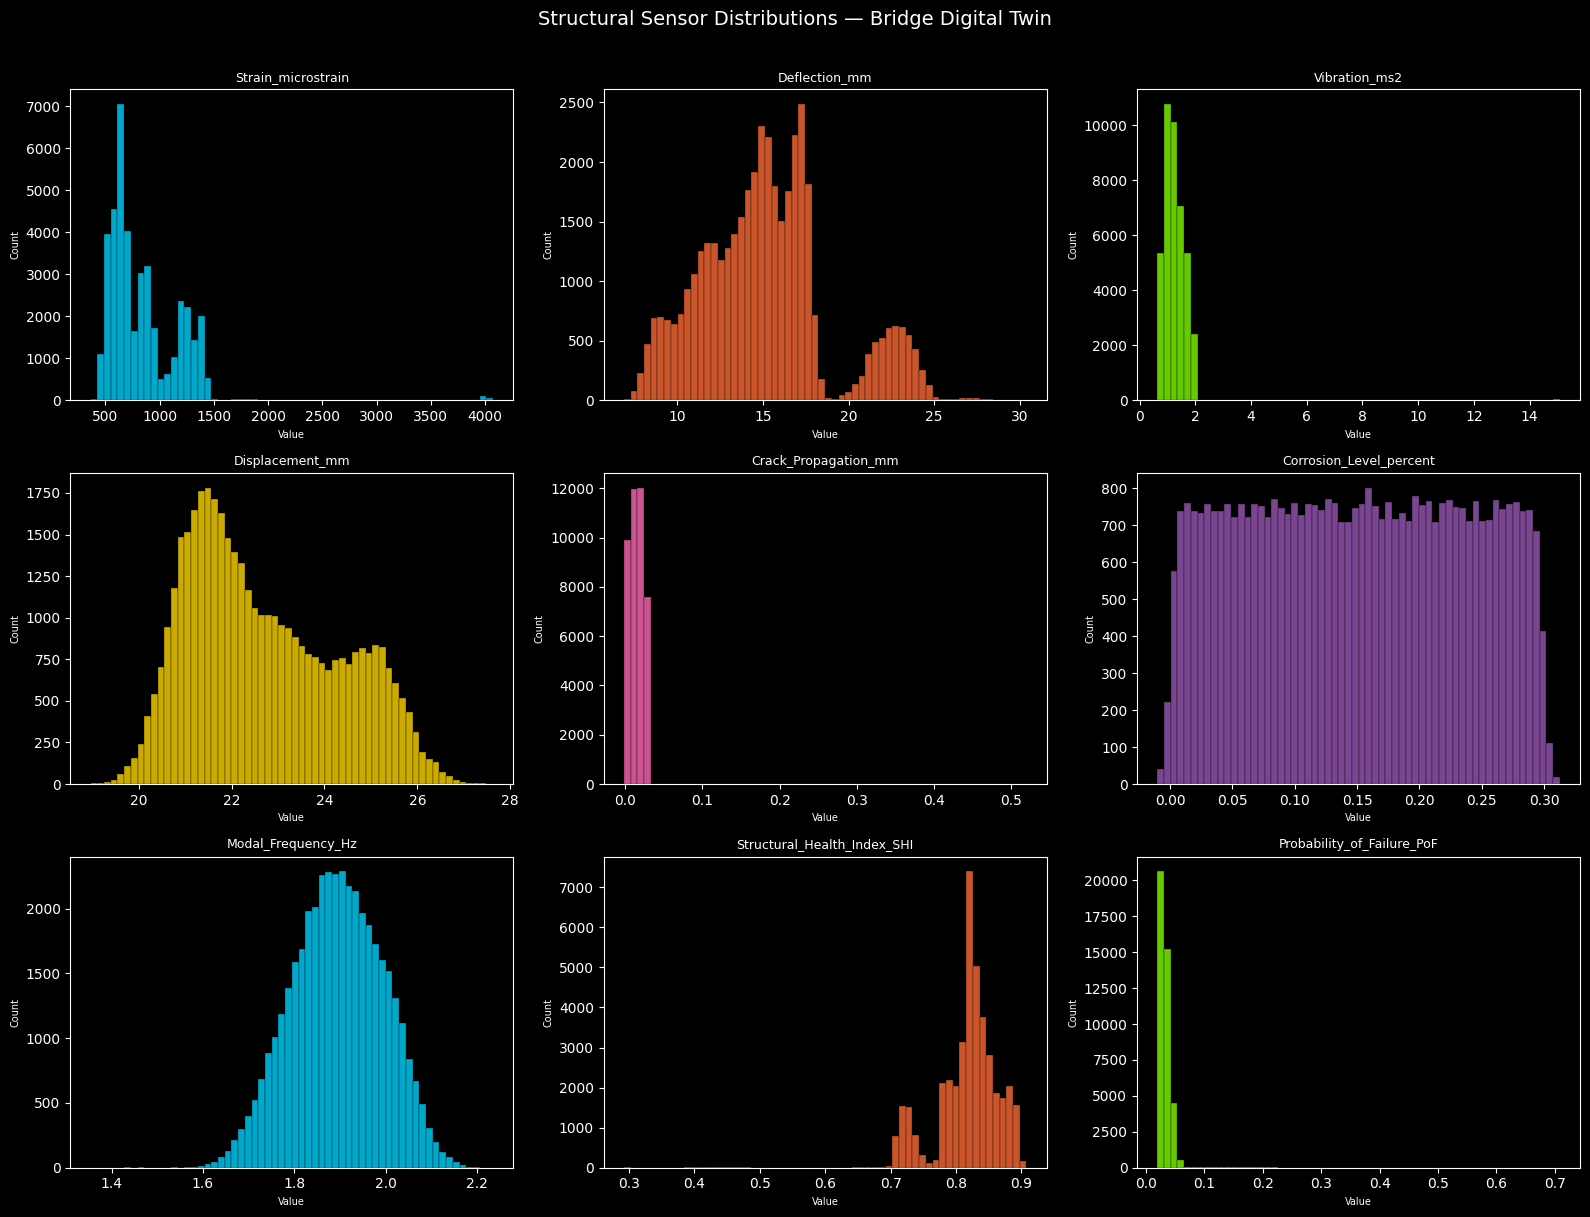

In [43]:
# Distribution plots for structural health indicators
fig, axes = mpl.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(KEY_STRUCTURAL):
    if col in dt.columns:
        axes[i].hist(dt[col].dropna(), bins=60, color=PALETTE[i % len(PALETTE)], 
                     alpha=0.8, edgecolor='black', linewidth=0.3)
        axes[i].set_title(col, fontsize=9, color='white')
        axes[i].set_xlabel('Value', fontsize=7)
        axes[i].set_ylabel('Count', fontsize=7)

mpl.suptitle('Structural Sensor Distributions — Bridge Digital Twin', 
             fontsize=14, color='white', y=1.01)
mpl.tight_layout()
mpl.savefig('figures/distributions.png', dpi=150, bbox_inches='tight')
mpl.show() 	15.086480

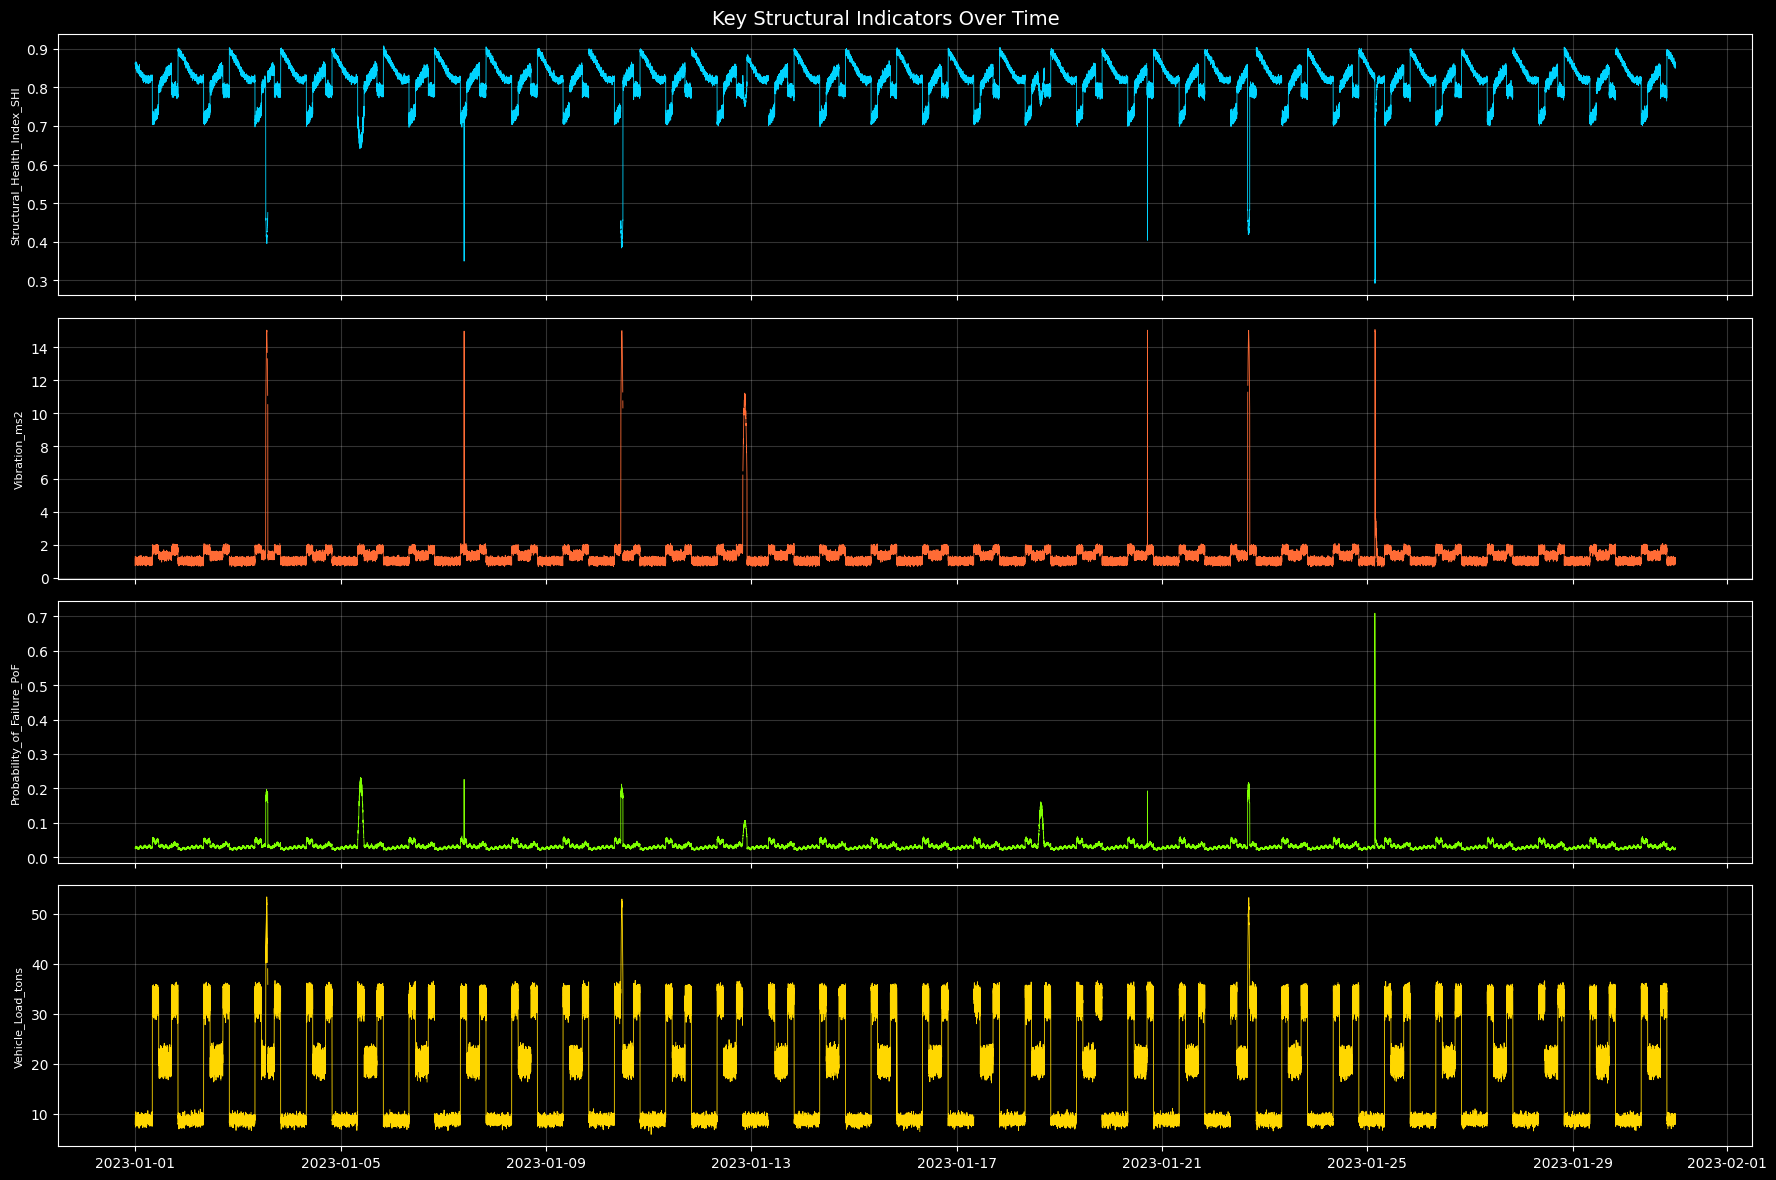

In [46]:
# Timeseries analysis
fig, axes = mpl.subplots(4, 1, figsize=(18, 12), sharex=True)
ts_cols = ['Structural_Health_Index_SHI', 'Vibration_ms2', 
           'Probability_of_Failure_PoF', 'Vehicle_Load_tons']

for ax, col in zip(axes, ts_cols):
    if col in dt.columns:
        ax.plot(dt['Timestamp'], dt[col], linewidth=0.6, color=PALETTE[ts_cols.index(col)])
        ax.set_ylabel(col, fontsize=8)
        ax.grid(alpha=0.2)

mpl.suptitle('Key Structural Indicators Over Time', fontsize=14, color='white')
mpl.tight_layout()
mpl.savefig('figures/timeseries_overview.png', dpi=150, bbox_inches='tight')
mpl.show()

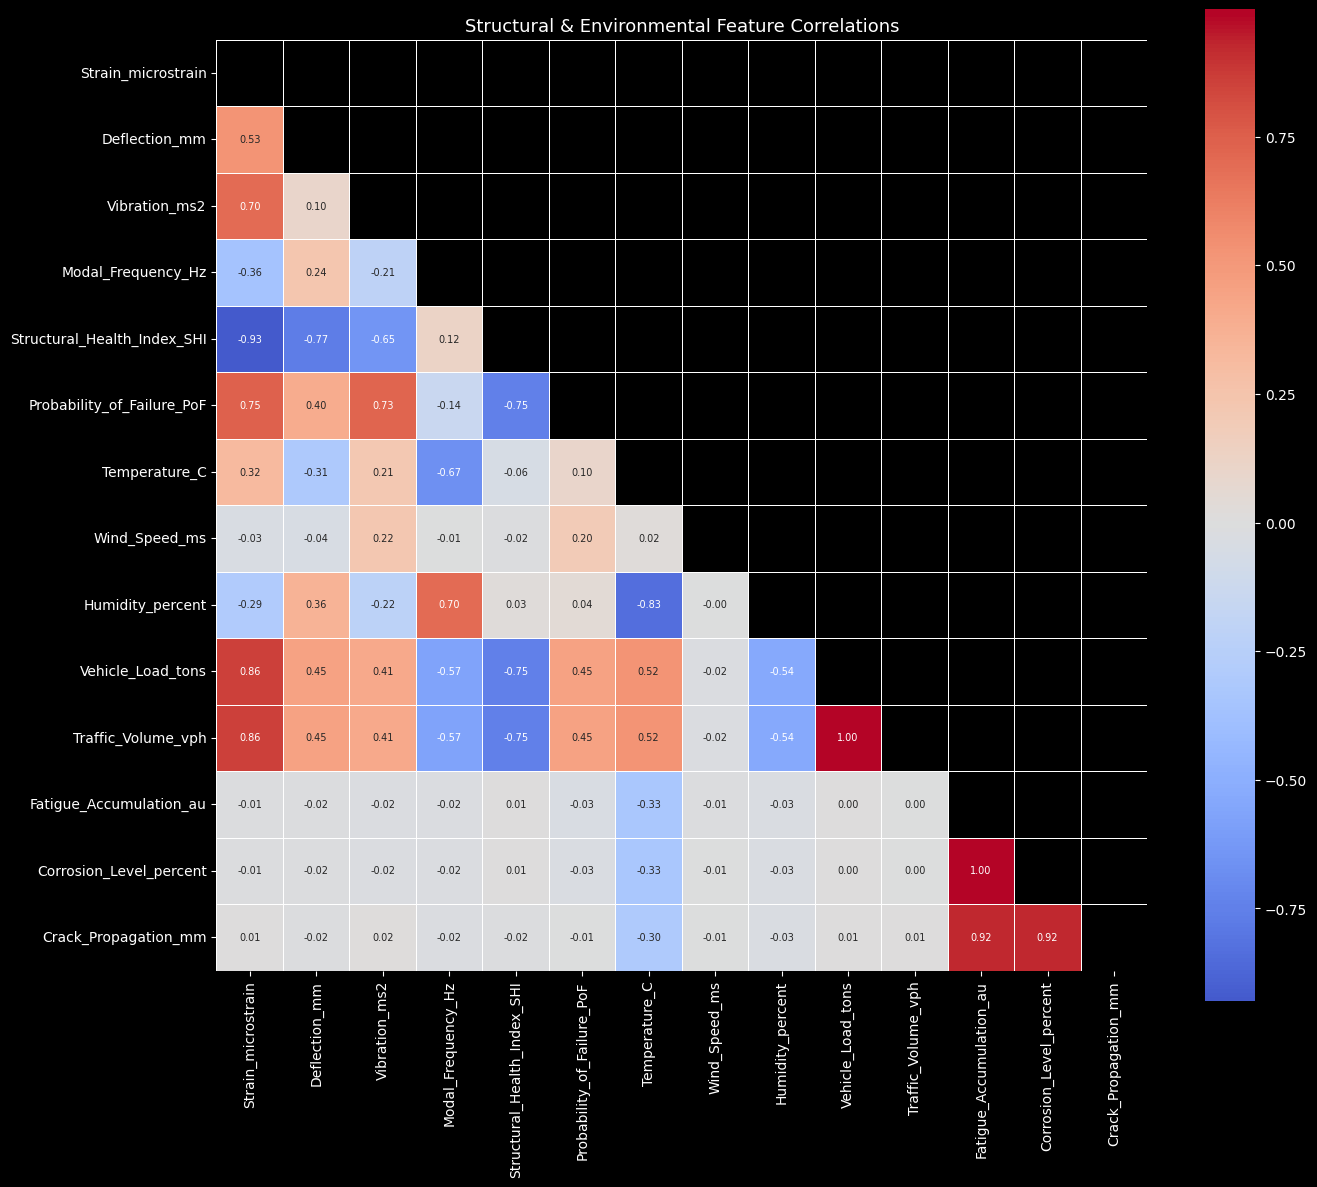

In [49]:
# Correlation Heatmap
CORR_COLS = [
    'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2', 'Modal_Frequency_Hz',
    'Structural_Health_Index_SHI', 'Probability_of_Failure_PoF',
    'Temperature_C', 'Wind_Speed_ms', 'Humidity_percent',
    'Vehicle_Load_tons', 'Traffic_Volume_vph', 'Fatigue_Accumulation_au',
    'Corrosion_Level_percent', 'Crack_Propagation_mm'
]
CORR_COLS = [c for c in CORR_COLS if c in dt.columns]

fig, ax = mpl.subplots(figsize=(14, 12))
corr = dt[CORR_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Structural & Environmental Feature Correlations', fontsize=13, color='white')
mpl.tight_layout()
mpl.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
mpl.show()

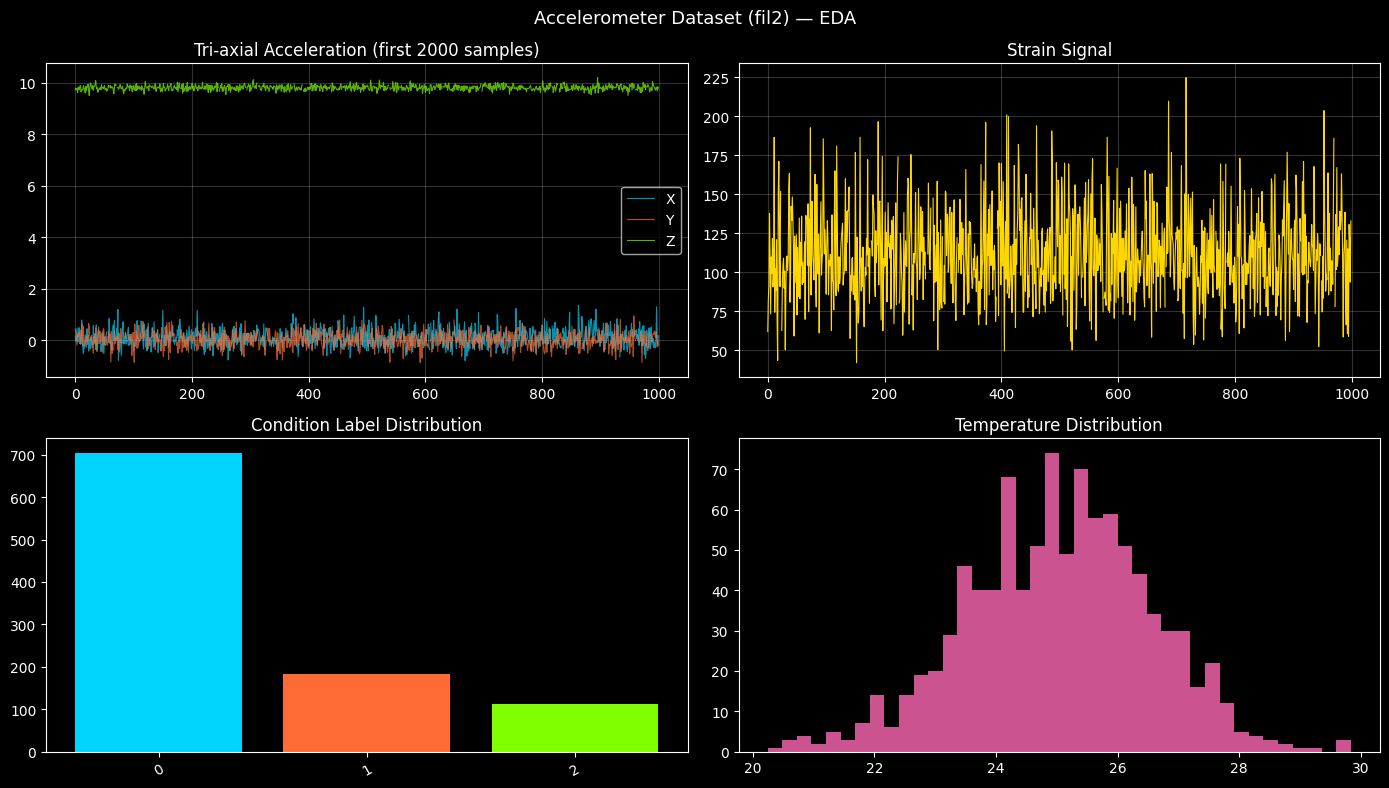

In [51]:
# Accelerometer dataset EDA
fig, axes = mpl.subplots(2, 2, figsize=(14, 8))

# Tri-axial acceleration
for ax_name, col, color in zip(['X','Y','Z'], 
    ['Accel_X (m/s^2)', 'Accel_Y (m/s^2)', 'Accel_Z (m/s^2)'], PALETTE):
    axes[0,0].plot(acc[col].values[:2000], alpha=0.7, label=ax_name, color=color, linewidth=0.8)
axes[0,0].set_title('Tri-axial Acceleration (first 2000 samples)')
axes[0,0].legend()
axes[0,0].grid(alpha=0.2)

# Strain
axes[0,1].plot(acc['Strain (με)'].values[:2000], color=PALETTE[3], linewidth=0.8)
axes[0,1].set_title('Strain Signal')
axes[0,1].grid(alpha=0.2)

# Condition label distribution
if 'Condition Label' in acc.columns:
    label_counts = acc['Condition Label'].value_counts()
    axes[1,0].bar(label_counts.index.astype(str), label_counts.values, color=PALETTE[:len(label_counts)])
    axes[1,0].set_title('Condition Label Distribution')
    axes[1,0].tick_params(axis='x', rotation=30)

# Temperature distribution
axes[1,1].hist(acc['Temp (°C)'].dropna(), bins=40, color=PALETTE[4], alpha=0.8)
axes[1,1].set_title('Temperature Distribution')

mpl.suptitle('Accelerometer Dataset (fil2) — EDA', fontsize=13)
mpl.tight_layout()
mpl.savefig('figures/acc_eda.png', dpi=150, bbox_inches='tight')
mpl.show()